# Formulaic Alphas — Batch 1

Screens 5 cross-sectional price/volume alphas from Kakushadze & Tulchinsky (2015),
**"101 Formulaic Alphas"**, on the current S&P 500 universe: `alpha_101`, `alpha_12`,
`alpha_20`, `alpha_9`, `alpha_19` (numbering follows the paper).

**Purpose:** comparison / screening, not a deep-dive. Any alpha that looks promising
here gets its own dedicated notebook later, matching the existing per-signal pattern
(e.g. `yield_curve_regime.ipynb`).

**Scope:** all 5 alphas use only adjusted close / open / high / low / volume — no
vwap, no industry classification, no market cap. Each is evaluated as a daily-rebalanced,
cross-sectional decile long/short, equal-weighted, dollar-neutral portfolio.

## ⚠️ Known limitation — survivorship bias

This notebook pulls OHLCV for the **current** S&P 500 constituent list only (503
tickers, resolved once via `EquityCollector.get_sp500_tickers()` and stored in
`assets`). It does **not** reconstruct historical index membership at each point in
time. Names that were removed from the index (bankruptcies, acquisitions, delistings)
are entirely absent from this backtest, which biases returns upward relative to a
point-in-time-correct universe. This is a known, accepted limitation for a first-pass
screen — **not fixed here**. A promising alpha's deep-dive notebook should revisit
this before drawing capital-allocation conclusions.

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Ensure the project root is the working directory so data/quant.db resolves correctly.
_cwd = os.getcwd()
while _cwd != os.path.dirname(_cwd):
    if os.path.exists(os.path.join(_cwd, 'data', 'quant.db')):
        break
    _cwd = os.path.dirname(_cwd)
os.chdir(_cwd)
print('Working directory:', os.getcwd())

from src.db.client import db
from src.backtest.reference import ReferenceData
from src.backtest.execution import apply_costs
from src.backtest.backtest import run_backtest

db.open()
print('DB open')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
sns.set_style('whitegrid')

# Categorical palette (validated, fixed-order -- see dataviz skill palette.md)
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
DIVERGING = mcolors.LinearSegmentedColormap.from_list(
    'blue_gray_red', ['#2a78d6', '#f0efec', '#e34948']
)
print('Setup complete.')

Working directory: /Users/rhlbh/projects/claudeProjects/quant


2026-08-01 12:27:04 [INFO] Opening DuckDB at data/quant.db
2026-08-01 12:27:04 [INFO] DB schema up to date (version 7)


DB open
Setup complete.


## 1. Load Universe & Build Panels

Pull daily OHLCV for every current S&P 500 constituent (`assets.asset_class = 'equity'`,
`id < 100000` — this excludes the fixed-ID equity *indices* block at `100001+`, which
share `asset_class = 'equity'` but are not constituents). Pivot into wide date × ticker
panels, one per OHLCV field.

**Coverage rule:** a day is only used for cross-sectional computation once at least
`MIN_COVERAGE = 200` names have valid OHLCV that day. Days below threshold are dropped
and the drop count is logged. In practice every calendar day from 2000-01-03 onward
already clears 200 names (this DB's earliest constituent history), so this rule ends
up defining "longest available common history" empirically rather than truncating
anything by hand.

In [2]:
MIN_COVERAGE = 200

raw = db.query_df("""
    SELECT a.ticker AS ticker,
           timezone('UTC', p.timestamp)::DATE AS d,
           p.open, p.high, p.low, p.close, p.volume
    FROM prices p
    JOIN assets a ON a.id = p.asset_id
    WHERE a.asset_class = 'equity' AND a.id < 100000 AND p.interval = '1d'
    ORDER BY d, ticker
""")
raw['d'] = pd.to_datetime(raw['d'])
print(f'Raw rows: {len(raw):,}  |  tickers: {raw["ticker"].nunique()}')

open_df   = raw.pivot(index='d', columns='ticker', values='open')
high_df   = raw.pivot(index='d', columns='ticker', values='high')
low_df    = raw.pivot(index='d', columns='ticker', values='low')
close_df  = raw.pivot(index='d', columns='ticker', values='close')
volume_df = raw.pivot(index='d', columns='ticker', values='volume')

coverage = close_df.notna().sum(axis=1)
keep_days = coverage[coverage >= MIN_COVERAGE].index
n_dropped = len(coverage) - len(keep_days)

print(f'\nDays in raw panel      : {len(coverage):,}')
print(f'Days below MIN_COVERAGE : {n_dropped:,} (threshold={MIN_COVERAGE})')
print(f'Days retained           : {len(keep_days):,}')

open_df, high_df, low_df, close_df, volume_df = (
    f.loc[keep_days] for f in (open_df, high_df, low_df, close_df, volume_df)
)

print(f'\nRetained panel range: {open_df.index[0].date()} -> {open_df.index[-1].date()}')
print(f'Names in panel: {open_df.shape[1]}')

Raw rows: 2,945,373  |  tickers: 499

Days in raw panel      : 6,679
Days below MIN_COVERAGE : 0 (threshold=200)
Days retained           : 6,679

Retained panel range: 2000-01-03 -> 2026-07-24
Names in panel: 499


## 2. Alpha Definitions

Each function takes the five panels (`open_df, high_df, low_df, close_df, volume_df`)
and returns a raw score panel of the same shape (date × ticker). `rank(...)` always
means a same-day cross-sectional rank across names (`DataFrame.rank(axis=1)`, which
skips `NaN` automatically — the ranking universe on a given day is exactly the names
with a valid score that day).

In [3]:
def alpha_101(open_df, high_df, low_df, close_df, volume_df):
    # (close - open) / (high - low + 0.001)
    return (close_df - open_df) / (high_df - low_df + 0.001)


def alpha_12(open_df, high_df, low_df, close_df, volume_df):
    # sign(volume.diff(1)) * -1 * close.diff(1)
    return np.sign(volume_df.diff(1)) * -1 * close_df.diff(1)


def alpha_20(open_df, high_df, low_df, close_df, volume_df):
    # -1 * rank(open - high[1]) * rank(open - close[1]) * rank(open - low[1])
    r1 = (open_df - high_df.shift(1)).rank(axis=1)
    r2 = (open_df - close_df.shift(1)).rank(axis=1)
    r3 = (open_df - low_df.shift(1)).rank(axis=1)
    return -1 * r1 * r2 * r3


def alpha_9(open_df, high_df, low_df, close_df, volume_df):
    # Consistent 5-day trend -> momentum; mixed -> fade the last move.
    d1 = close_df.diff(1)
    roll_min = d1.rolling(5).min()
    roll_max = d1.rolling(5).max()

    cond_up = roll_min > 0
    cond_down = roll_max < 0
    warmup = roll_min.isna() | roll_max.isna()

    score = np.where(cond_up | cond_down, d1, -d1)
    score = np.where(warmup, np.nan, score)
    return pd.DataFrame(score, index=d1.index, columns=d1.columns)


def alpha_19(open_df, high_df, low_df, close_df, volume_df):
    # Fade the 7-day move, scaled by cross-sectional 250-day momentum rank.
    returns_df = close_df.pct_change()
    trend7 = close_df - close_df.shift(7)
    cum250 = returns_df.rolling(250).sum()
    long_horizon_rank = (1 + cum250).rank(axis=1)
    return -np.sign(trend7) * (1 + long_horizon_rank)


def alpha_33(open_df, high_df, low_df, close_df, volume_df):
    # rank(-1 * (1 - (open / close)))
    raw = -1 * (1 - (open_df / close_df))
    return raw.rank(axis=1)


def alpha_54(open_df, high_df, low_df, close_df, volume_df):
    # (-1 * ((low - close) * open^5)) / ((low - high) * close^5)
    # No epsilon in the original formula. (low - high) == 0 only when
    # high == low (a zero-range bar) -> +/-inf, which rank(axis=1) would
    # silently treat as the top decile instead of "undefined". Guard it
    # the same way alpha_101's +0.001 guards (high - low).
    numerator = -1 * (low_df - close_df) * (open_df ** 5)
    denominator = (low_df - high_df) * (close_df ** 5)
    denominator = denominator.replace(0.0, np.nan)
    return numerator / denominator


def alpha_3(open_df, high_df, low_df, close_df, volume_df):
    # -1 * correlation(rank(open), rank(volume), 10)
    rank_open = open_df.rank(axis=1)
    rank_volume = volume_df.rank(axis=1)
    return -1 * rank_open.rolling(10).corr(rank_volume)


def alpha_4(open_df, high_df, low_df, close_df, volume_df):
    # -1 * Ts_Rank(rank(low), 9)
    # Ts_Rank = time-series rank (today's value vs. its own trailing window),
    # NOT the cross-sectional rank() used elsewhere -- this is a different axis.
    rank_low = low_df.rank(axis=1)
    return -1 * rank_low.rolling(9).rank()


def alpha_22(open_df, high_df, low_df, close_df, volume_df):
    # -1 * (delta(correlation(high, volume, 5), 5) * rank(stddev(close, 20)))
    corr_hv = high_df.rolling(5).corr(volume_df)
    delta_corr = corr_hv - corr_hv.shift(5)
    rank_std = close_df.rolling(20).std().rank(axis=1)
    return -1 * (delta_corr * rank_std)

ALPHA_FNS = {
    'alpha_101': alpha_101,
    'alpha_12': alpha_12,
    'alpha_20': alpha_20,
    'alpha_9': alpha_9,
    'alpha_19': alpha_19,
    'alpha_33': alpha_33,
    'alpha_54': alpha_54,
    'alpha_3': alpha_3,
    'alpha_4': alpha_4,
    'alpha_22': alpha_22,
}

scores = {
    name: fn(open_df, high_df, low_df, close_df, volume_df)
    for name, fn in ALPHA_FNS.items()
}
for name, s in scores.items():
    print(f'{name:<10s}  valid obs/day (median): {s.notna().sum(axis=1).median():.0f}')

alpha_101   valid obs/day (median): 451
alpha_12    valid obs/day (median): 451
alpha_20    valid obs/day (median): 451
alpha_9     valid obs/day (median): 451
alpha_19    valid obs/day (median): 442
alpha_33    valid obs/day (median): 451
alpha_54    valid obs/day (median): 450
alpha_3     valid obs/day (median): 447
alpha_4     valid obs/day (median): 451
alpha_22    valid obs/day (median): 451


**Note on `alpha_19`:** this fades the 7-day price move (`-sign(close - close[7])`),
but scales the bet up for names with a stronger *cross-sectional rank* of 250-day
cumulative momentum — i.e. names that have run hardest over the past year get a bigger
short-term mean-reversion bet against their most recent 7-day move.

## 3. Portfolio Construction — Decile Long/Short

Applied identically to all 5 alphas:

- Each day, rank valid scores cross-sectionally into 10 deciles (ties broken by
  order via `method='first'` so decile boundaries are well-defined).
- Long the top decile, short the bottom decile, equal-weighted within each side.
- Weights scale so gross long = 1.0 and gross short = 1.0 (dollar-neutral,
  self-financing).
- A day needs at least `MIN_COVERAGE` (200) names with a valid score to form deciles;
  below that the portfolio holds no position that day (flat, zero P&L) rather than
  trading a thin, unreliable cross-section. This only binds during each alpha's own
  rolling-window warmup at the very start of the sample (e.g. `alpha_19`'s 250-day
  window) — the raw OHLCV coverage never drops below 200 once past 2000-01-03.
- Forward return: weight decided at close of day *t* earns the close-to-close return
  realized from *t* to *t+1*. This is exactly `apply_costs`'s `lag=1` execution
  convention, so the execution layer is reused here directly instead of re-deriving
  the lag mechanic by hand.
- `cost_bps=0.0` for this construction step too — no transaction cost modeling this
  pass (see note in section 4); `gross_returns == net_returns` as a result.

In [13]:
def decile_weights(score_df, n_deciles=10, min_names=MIN_COVERAGE):
    # Cross-sectional decile long/short weights, dollar-neutral (gross 1.0 / 1.0 each side).
    # Returns (weight_df, top_mask, bottom_mask, valid_count).
    valid_count = score_df.notna().sum(axis=1)
    ranks = score_df.rank(axis=1, method='first')

    decile = np.ceil(ranks.div(valid_count.replace(0, np.nan), axis=0) * n_deciles) - 1
    decile = decile.clip(upper=n_deciles - 1)

    top_mask = decile == (n_deciles - 1)
    bottom_mask = decile == 0

    insufficient = valid_count < min_names
    top_mask = top_mask.where(~insufficient, False)
    bottom_mask = bottom_mask.where(~insufficient, False)

    top_n = top_mask.sum(axis=1)
    bottom_n = bottom_mask.sum(axis=1)

    weight_df = (
        top_mask.astype(float).div(top_n.replace(0, np.nan), axis=0).fillna(0.0)
        - bottom_mask.astype(float).div(bottom_n.replace(0, np.nan), axis=0).fillna(0.0)
    )

    return weight_df, top_mask, bottom_mask, valid_count


def decile_churn(mask_df):
    # Fraction of a decile's membership that turned over vs. the prior valid day.
    prev = mask_df.shift(1).fillna(False)
    changed = (mask_df & ~prev) | (~mask_df & prev)
    n = mask_df.sum(axis=1)
    with np.errstate(invalid='ignore'):
        frac = changed.sum(axis=1) / (2 * n.replace(0, np.nan))
    return frac.iloc[1:]  # drop first day (spurious 100% churn vs. an empty "prior" state)


returns_df = close_df.pct_change()

alpha_returns = {}
turnover_membership = {}
turnover_asset_level = {}
insufficient_days = {}

for name, score_df in scores.items():
    weight_df, top_mask, bottom_mask, valid_count = decile_weights(score_df)

    insufficient_days[name] = int((valid_count < MIN_COVERAGE).sum())

    result = apply_costs(weights=weight_df, asset_returns=returns_df, cost_bps=0.001, lag=1)
    alpha_returns[name] = result.net_returns.rename(name)

    top_churn = decile_churn(top_mask)
    bottom_churn = decile_churn(bottom_mask)
    turnover_membership[name] = float(((top_churn + bottom_churn) / 2).mean())
    turnover_asset_level[name] = result.summary()['ann_turnover']

    print(f'{name:<10s}  obs={len(result.net_returns):>6,}  '
          f'insufficient-coverage days={insufficient_days[name]:>4}  '
          f'membership churn/day={turnover_membership[name]:.3f}')

alpha_101   obs= 6,678  insufficient-coverage days=   0  membership churn/day=0.946
alpha_12    obs= 6,678  insufficient-coverage days=   1  membership churn/day=0.878
alpha_20    obs= 6,678  insufficient-coverage days=   1  membership churn/day=0.924
alpha_9     obs= 6,678  insufficient-coverage days=   5  membership churn/day=0.894
alpha_19    obs= 6,678  insufficient-coverage days= 250  membership churn/day=0.654
alpha_33    obs= 6,678  insufficient-coverage days=   0  membership churn/day=0.924
alpha_54    obs= 6,678  insufficient-coverage days=   0  membership churn/day=0.941
alpha_3     obs= 6,678  insufficient-coverage days=   9  membership churn/day=0.677
alpha_4     obs= 6,678  insufficient-coverage days=   8  membership churn/day=0.836
alpha_22    obs= 6,678  insufficient-coverage days=  19  membership churn/day=0.748


## 4. Backtest Evaluation

Load reference/factor data once, same pattern as `backtest_stack_validation.ipynb`.
Then run each alpha's finished daily return series through the shared `run_backtest`
wrapper — using a constant `weight=1.0` "exposure" trick, since the alpha's decile
long/short mechanic (including the *t → t+1* lag) is already baked into `alpha_return`
by the execution-layer call in section 3. `lag=0` here is therefore a no-op, not a
missing lag: applying `apply_costs`' lag again would double-lag the returns, same
caveat as the trend notebook's "do not pre-shift" warning.

Before wiring the comparison table, confirm what `run_backtest` actually returns.

In [14]:
earliest_common_date = open_df.index[0].strftime('%Y-%m-%d')
rd = ReferenceData(start=earliest_common_date).load()
print('Reference factors loaded:', rd.available())

2026-08-01 12:46:39 [WARNING] [ReferenceData] Failed to load factor 'equities': Database not open. Call db.open() first.
2026-08-01 12:46:39 [WARNING] [ReferenceData] Failed to load factor 'dollar': Database not open. Call db.open() first.
2026-08-01 12:46:39 [WARNING] [ReferenceData] Failed to load factor 'gold': Database not open. Call db.open() first.
2026-08-01 12:46:39 [WARNING] [ReferenceData] Failed to load factor 'crude': Database not open. Call db.open() first.


Reference factors loaded: []


In [15]:
# Inspect the BacktestReport shape before relying on any field names.
_probe_name = next(iter(alpha_returns))
_probe_exposure = pd.Series(1.0, index=alpha_returns[_probe_name].index, name=f'{_probe_name}_weight')
_probe_report = run_backtest(
    weights=_probe_exposure,
    asset_returns=alpha_returns[_probe_name],
    cost_bps=0.0,
    lag=0,
    name=f'{_probe_name}_decile_ls',
    verbose=False,
)
print('BacktestReport public attributes:')
print([a for a in dir(_probe_report) if not a.startswith('_')])
print('\nperformance.metrics() keys:')
print(list(_probe_report.performance.metrics().keys()))
print('\nexecution.summary() (expect ann_turnover ~ 0 -- this is the constant-weight trick, '
      'not the real decile turnover computed in section 3):')
print(_probe_report.execution.summary())

2026-08-01 12:46:45 [WARNING] [ReferenceData] Failed to load factor 'volatility': Database not open. Call db.open() first.
2026-08-01 12:46:45 [WARNING] [VolRegime:volatility] No level data for factor 'volatility' — labels() will return an empty Series.
2026-08-01 12:46:45 [WARNING] [Conditioner] Regime 'volatility' returned empty labels — omitting from by_regime().
2026-08-01 12:46:45 [WARNING] [ReferenceData] Failed to load factor 'rates_curve': Database not open. Call db.open() first.
2026-08-01 12:46:45 [WARNING] [RatesRegime:rates_curve] No level data for factor 'rates_curve' — labels() will return an empty Series.
2026-08-01 12:46:45 [WARNING] [Conditioner] Regime 'rates_curve' returned empty labels — omitting from by_regime().
2026-08-01 12:46:45 [WARNING] [ReferenceData] Failed to load factor 'equity_trend': Database not open. Call db.open() first.
2026-08-01 12:46:45 [WARNING] [TrendRegime:equity_trend] No level data for factor 'equity_trend' — labels() will return an empty Se

BacktestReport public attributes:
['betas', 'by_regime', 'conditional_perf', 'conditioning', 'correlations', 'execution', 'factor_regression', 'name', 'performance', 'rolling_corr', 'yearly']

performance.metrics() keys:
['total_return', 'cagr', 'ann_return', 'ann_vol', 'sharpe', 'sortino', 'calmar', 'max_drawdown', 'max_dd_duration', 'skew', 'excess_kurtosis', 'hit_rate', 'win_loss_ratio', 'var_95', 'cvar_95', 'best_day', 'worst_day', 'sharpe_tstat', 'n_periods', 'start', 'end']

execution.summary() (expect ann_turnover ~ 0 -- this is the constant-weight trick, not the real decile turnover computed in section 3):
{'total_gross': -0.9929465577562266, 'total_net': -0.9929465577562266, 'total_cost': 0.0, 'avg_turnover': 0.0, 'ann_turnover': 0.0}


In [16]:
reports = {}
for name, ret in alpha_returns.items():
    exposure = pd.Series(1.0, index=ret.index, name=f'{name}_weight')
    reports[name] = run_backtest(
        weights=exposure,
        asset_returns=ret,
        cost_bps=0.0,
        lag=0,
        name=f'{name}_decile_ls',
        verbose=False,
    )
print(f'Ran {len(reports)} backtests: {list(reports.keys())}')

2026-08-01 12:46:46 [WARNING] [ReferenceData] Failed to load factor 'volatility': Database not open. Call db.open() first.
2026-08-01 12:46:46 [WARNING] [VolRegime:volatility] No level data for factor 'volatility' — labels() will return an empty Series.
2026-08-01 12:46:46 [WARNING] [Conditioner] Regime 'volatility' returned empty labels — omitting from by_regime().
2026-08-01 12:46:46 [WARNING] [ReferenceData] Failed to load factor 'rates_curve': Database not open. Call db.open() first.
2026-08-01 12:46:46 [WARNING] [RatesRegime:rates_curve] No level data for factor 'rates_curve' — labels() will return an empty Series.
2026-08-01 12:46:46 [WARNING] [Conditioner] Regime 'rates_curve' returned empty labels — omitting from by_regime().
2026-08-01 12:46:46 [WARNING] [ReferenceData] Failed to load factor 'equity_trend': Database not open. Call db.open() first.
2026-08-01 12:46:46 [WARNING] [TrendRegime:equity_trend] No level data for factor 'equity_trend' — labels() will return an empty Se

Ran 10 backtests: ['alpha_101', 'alpha_12', 'alpha_20', 'alpha_9', 'alpha_19', 'alpha_33', 'alpha_54', 'alpha_3', 'alpha_4', 'alpha_22']


## 5. Comparison

Summary table pulls annualized return / vol / Sharpe / hit rate from each
`report.performance.metrics()`. The **membership-based turnover** diagnostic
(avg. daily fraction of names entering/leaving the top or bottom decile) is
computed directly in section 3 from decile masks — `run_backtest`'s own
`ann_turnover` reads ~0 given the constant-`weight=1.0` trick and is not a
turnover measure of the actual strategy. The asset-level `ann_turnover` from the
internal `apply_costs` call in section 3 (real per-name weight changes) is included
alongside it as a cross-check — the two should tell a broadly consistent turnover
story even though they measure different things (membership churn vs. weight
changes).

In [17]:
summary_rows = []
for name, report in reports.items():
    m = report.performance.metrics()
    summary_rows.append({
        'alpha': name,
        'ann_return': m['ann_return'],
        'ann_vol': m['ann_vol'],
        'sharpe': m['sharpe'],
        'hit_rate': m['hit_rate'],
        'membership_churn/day': turnover_membership[name],
        'ann_turnover (asset-level, bonus)': turnover_asset_level[name],
    })

summary_df = pd.DataFrame(summary_rows).set_index('alpha')
summary_df

,ann_return,ann_vol,sharpe,hit_rate,membership_churn/day,"ann_turnover (asset-level, bonus)"
alpha,,,,,,
alpha_101,-0.174949,0.154183,-1.134684,0.456424,0.945558,449.081324
alpha_12,-0.026823,0.108093,-0.248145,0.500898,0.877927,380.955127
alpha_20,0.071964,0.145488,0.494638,0.513777,0.924035,427.423778
alpha_9,0.057144,0.148155,0.385706,0.520665,0.893714,396.636468
alpha_19,0.105364,0.140064,0.752254,0.496107,0.653583,149.088321
alpha_33,0.201978,0.203483,0.992603,0.530698,0.924317,427.668322
alpha_54,0.331431,0.125590,2.639001,0.581162,0.940601,444.106059
alpha_3,0.063802,0.092673,0.688468,0.515274,0.676874,178.480201
alpha_4,0.157878,0.154069,1.024721,0.518568,0.835564,337.904153


In [9]:
returns_panel = pd.DataFrame(alpha_returns)
corr_matrix = returns_panel.corr()

off_diag = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool))
avg_pairwise_corr = off_diag.stack().mean()

print(f'Average pairwise correlation across these 5 alphas: {avg_pairwise_corr:.3f}')
print('Kakushadze (2015) reports ~16% average pairwise correlation across the full set of 101.')
corr_matrix

Average pairwise correlation across these 5 alphas: 0.104
Kakushadze (2015) reports ~16% average pairwise correlation across the full set of 101.


,alpha_101,alpha_12,alpha_20,alpha_9,alpha_19,alpha_33,alpha_54,alpha_3,alpha_4,alpha_22
alpha_101,1.000000,-0.299419,-0.153416,-0.686424,-0.197893,-0.843259,-0.566003,-0.171388,-0.459381,-0.181587
alpha_12,-0.299419,1.000000,0.212640,0.287358,0.123091,0.301397,0.085052,0.140029,0.353695,0.208203
alpha_20,-0.153416,0.212640,1.000000,0.340735,0.166813,0.095076,0.083458,0.098969,0.426973,0.131221
alpha_9,-0.686424,0.287358,0.340735,1.000000,0.129698,0.711555,0.390706,0.047897,0.343433,0.117125
alpha_19,-0.197893,0.123091,0.166813,0.129698,1.000000,0.203596,0.216010,0.173939,0.408625,0.140648
alpha_33,-0.843259,0.301397,0.095076,0.711555,0.203596,1.000000,0.453661,0.142284,0.436395,0.173868
alpha_54,-0.566003,0.085052,0.083458,0.390706,0.216010,0.453661,1.000000,0.065396,0.230969,0.063983
alpha_3,-0.171388,0.140029,0.098969,0.047897,0.173939,0.142284,0.065396,1.000000,0.371478,0.070628
alpha_4,-0.459381,0.353695,0.426973,0.343433,0.408625,0.436395,0.230969,0.371478,1.000000,0.279605
alpha_22,-0.181587,0.208203,0.131221,0.117125,0.140648,0.173868,0.063983,0.070628,0.279605,1.000000


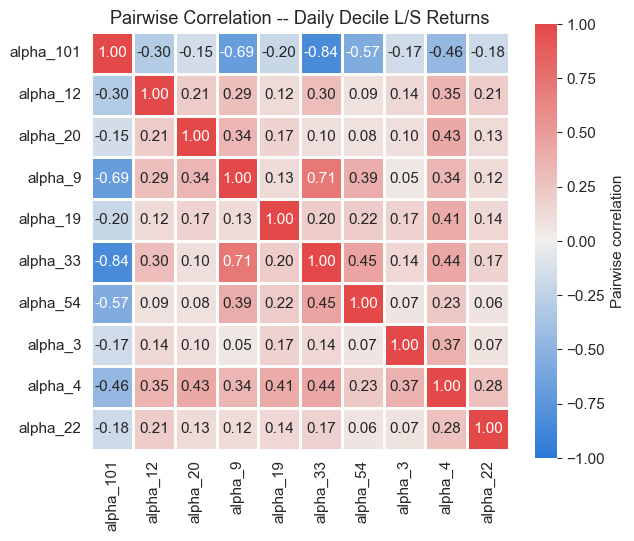

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap=DIVERGING, vmin=-1, vmax=1,
    center=0, square=True, linewidths=1, linecolor='#fcfcfb',
    cbar_kws={'label': 'Pairwise correlation'}, ax=ax,
)
ax.set_title('Pairwise Correlation -- Daily Decile L/S Returns', fontsize=13)
plt.tight_layout()
plt.show()

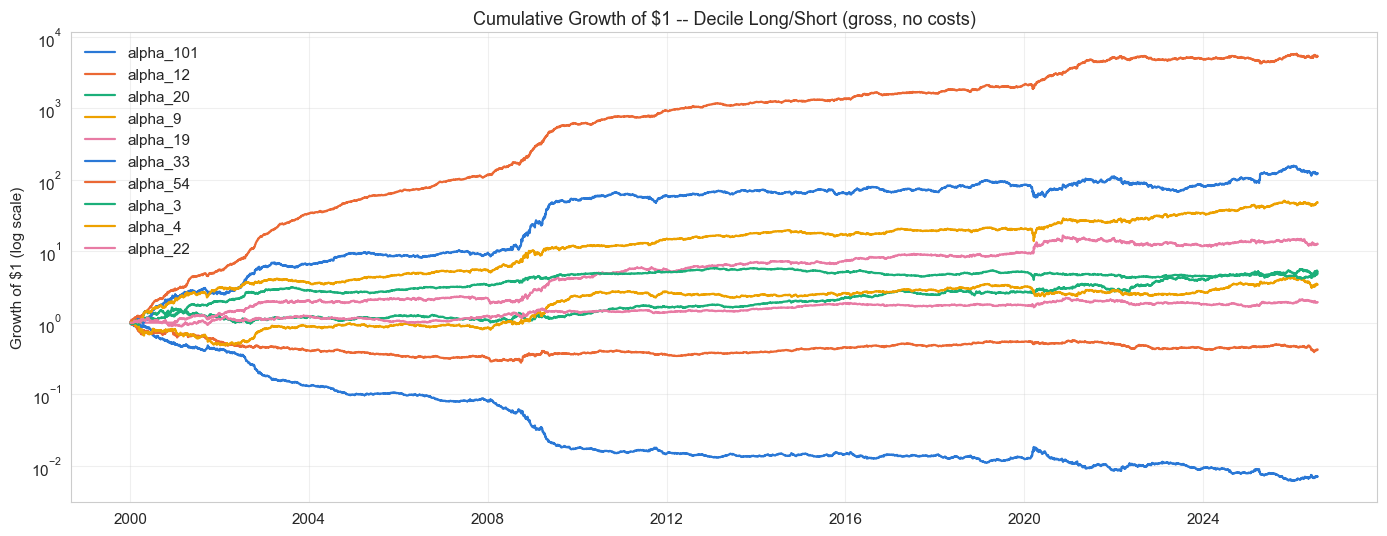

In [11]:
fig, ax = plt.subplots(figsize=(14, 5.5))
for i, (name, ret) in enumerate(alpha_returns.items()):
    equity = (1 + ret).cumprod()
    ax.plot(equity.index, equity.values, label=name, lw=1.6, color=PALETTE[i % len(PALETTE)])

ax.set_yscale('log')
ax.set_title('Cumulative Growth of $1 -- Decile Long/Short (gross, no costs)', fontsize=13)
ax.set_ylabel('Growth of $1 (log scale)')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

## 6. Notes / Caveats

- **Survivorship bias** (see top of notebook): current-constituents-only universe.
  Not fixed here.
- **No transaction costs modeled** this pass (`cost_bps=0.0` throughout). Given the
  daily-rebalance, decile-membership-churn turnover numbers above, costs would matter
  a lot for the higher-turnover alphas before any of this is investable — that
  belongs in a deep-dive, not this screen.
- **Next step:** whichever alpha(s) look best on Sharpe / correlation-to-the-others
  here get their own dedicated notebook (regime conditioning, factor regression,
  realistic cost assumptions, decile spread stability, etc.) — this notebook's job
  was only to screen and compare.

In [12]:
db.close()
print('DB closed')

2026-08-01 12:27:56 [INFO] DuckDB connection closed


DB closed
